In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wti_env import WTIEnv
from dqn_agent import DQNAgent

In [2]:
# === DAILY DATASET ===
df_daily = pd.read_csv("pomdp_data/wti_1_data_with_hurricanes.csv")
print("=== DAILY DATASET LOADED ===")
print(f"Shape: {df_daily.shape}")
print(f"Date range: {df_daily['Date'].min()} → {df_daily['Date'].max()}")
print("Columns:", df_daily.columns.tolist())

# === OVX + WEATHER + HURRICANES DATASET ===
df_ovx = pd.read_csv("ovx_data/wti_weather_hurricanes_ovx_since_2007.csv")
print("=== OVX DATASET LOADED ===")
print(f"Shape: {df_ovx.shape}")
print(f"Date range: {df_ovx['Date'].min()} → {df_ovx['Date'].max()}")
print("Columns:", df_ovx.columns.tolist())


from pomdp_model import resample_to_weekly

# Use the same feature definition as POMDP: all non-price/non-return columns
feature_cols_daily = [
    c for c in df_daily.columns
    if c not in ["Date", "ret_CL1", "spot_price", "CL1"]
]

df_weekly = resample_to_weekly(df_daily, feature_cols_daily, return_col="ret_CL1")

print("=== WEEKLY DATASET GENERATED FROM DAILY ===")
print(f"Shape: {df_weekly.shape}")
print(f"Date range: {df_weekly['Date'].min()} → {df_weekly['Date'].max()}")
print("Columns:", df_weekly.columns.tolist())


=== DAILY DATASET LOADED ===
Shape: (9586, 62)
Date range: 1986-01-02 → 2024-04-05
Columns: ['Date', 'spot_price', 'CL1', 'ret_CL1', 'alaska_temp', 'alaska_precip', 'bakken_temp', 'bakken_precip', 'western_canada_temp', 'western_canada_precip', 'midwest_corridor_temp', 'midwest_corridor_precip', 'ok_hub_temp', 'ok_hub_precip', 'permian_temp', 'permian_precip', 'rockies_temp', 'rockies_precip', 'texas_gulf_temp', 'texas_gulf_precip', 'bakken_temp_producing', 'bakken_precip_producing', 'canada_temp_producing', 'canada_precip_producing', 'eagle_temp_producing', 'eagle_precip_producing', 'central_kansas_temp_producing', 'central_kansas_precip_producing', 'n_alaska_temp_producing', 'n_alaska_precip_producing', 'nc_ok_temp_producing', 'nc_ok_precip_producing', 'ne_ok_temp_producing', 'ne_ok_precip_producing', 'nw_ok_temp_producing', 'nw_ok_precip_producing', 'permian_temp_producing', 'permian_precip_producing', 's_alaska_temp_producing', 's_alaska_precip_producing', 'saskatchewan_temp_produc

In [3]:
# ==========================
# DAILY DATA: FEATURES & SPLIT
# ==========================

df = df_daily.copy()

# Define features and target (same exclusions as original)
feature_cols_daily = [
    c for c in df.columns
    if c not in ['Date', 'ret_CL1', 'spot_price', 'CL1']
]
return_col = 'ret_CL1'

print("=== DAILY DATASET ===")
print(f"Number of features: {len(feature_cols_daily)}")
print("\nFeature types (per original breakdown):")
print("  - Pipeline weather (temp + precip): 16 features")
print("  - Producing region weather:        26 features")
print("  - Hurricane data:                  16 features")

# Check for NaN values in return column
nan_counts = df.isna().sum()
print(f"\nNaN values in {return_col}: {nan_counts[return_col]}")
print("(These will be automatically dropped during model fitting)")

# Time-based split (80% train, 20% test)
train_size = int(len(df) * 0.8)
train_daily = df.iloc[:train_size].copy()
test_daily = df.iloc[train_size:].copy()

print(f"\nTraining data (daily): {len(train_daily)} samples "
      f"({train_daily['Date'].min()} to {train_daily['Date'].max()})")
print(f"Test data (daily):     {len(test_daily)} samples "
      f"({test_daily['Date'].min()} to {test_daily['Date'].max()})")

# ==========================
# WEEKLY DATA (NO OVX): FEATURES & SPLIT
# ==========================

dfw = df_weekly.copy()

feature_cols_weekly = [
    c for c in dfw.columns
    if c not in ['Date', 'ret_CL1', 'spot_price', 'CL1']
]
return_col = 'ret_CL1'

print("=== WEEKLY DATASET (NO OVX) ===")
print(f"Number of features: {len(feature_cols_weekly)}")

nan_counts_w = dfw.isna().sum()
print(f"\nNaN values in {return_col}: {nan_counts_w[return_col]}")

# Time-based split (80% train, 20% test)
train_size_w = int(len(dfw) * 0.8)
train_weekly = dfw.iloc[:train_size_w].copy()
test_weekly = dfw.iloc[train_size_w:].copy()

print(f"\nTraining data (weekly): {len(train_weekly)} samples "
      f"({train_weekly['Date'].min()} to {train_weekly['Date'].max()})")
print(f"Test data (weekly):     {len(test_weekly)} samples "
      f"({test_weekly['Date'].min()} to {test_weekly['Date'].max()})")


# ==========================
# WEEKLY DATA WITH OVX: FEATURES & SPLIT
# ==========================

from pomdp_model import resample_to_weekly

# Start from OVX-augmented daily df
df_ovx_daily = df_ovx.copy()

feature_cols_ovx_daily = [
    c for c in df_ovx_daily.columns
    if c not in ['Date', 'ret_CL1', 'spot_price', 'CL1']
]

# Resample OVX dataset to weekly horizon (same as POMDP OVX experiment)
df_ovx_weekly = resample_to_weekly(df_ovx_daily, feature_cols_ovx_daily, return_col='ret_CL1')

feature_cols_ovx = [
    c for c in df_ovx_weekly.columns
    if c not in ['Date', 'ret_CL1', 'spot_price', 'CL1']
]
return_col = 'ret_CL1'

print("=== WEEKLY DATASET WITH OVX ===")
print(f"Number of features (incl. OVX): {len(feature_cols_ovx)}")

nan_counts_ovx = df_ovx_weekly.isna().sum()
print(f"\nNaN values in {return_col}: {nan_counts_ovx[return_col]}")

# Time-based split (80% train, 20% test)
train_size_ovx = int(len(df_ovx_weekly) * 0.8)
train_ovx = df_ovx_weekly.iloc[:train_size_ovx].copy()
test_ovx = df_ovx_weekly.iloc[train_size_ovx:].copy()

print(f"\nTraining data (weekly+OVX): {len(train_ovx)} samples "
      f"({train_ovx['Date'].min()} to {train_ovx['Date'].max()})")
print(f"Test data (weekly+OVX):     {len(test_ovx)} samples "
      f"({test_ovx['Date'].min()} to {test_ovx['Date'].max()})")


=== DAILY DATASET ===
Number of features: 58

Feature types (per original breakdown):
  - Pipeline weather (temp + precip): 16 features
  - Producing region weather:        26 features
  - Hurricane data:                  16 features

NaN values in ret_CL1: 3
(These will be automatically dropped during model fitting)

Training data (daily): 7668 samples (1986-01-02 to 2016-07-29)
Test data (daily):     1918 samples (2016-08-01 to 2024-04-05)
=== WEEKLY DATASET (NO OVX) ===
Number of features: 58

NaN values in ret_CL1: 0

Training data (weekly): 1597 samples (1986-01-05 00:00:00 to 2016-08-07 00:00:00)
Test data (weekly):     400 samples (2016-08-14 00:00:00 to 2024-04-07 00:00:00)
=== WEEKLY DATASET WITH OVX ===
Number of features (incl. OVX): 59

NaN values in ret_CL1: 0

Training data (weekly+OVX): 706 samples (2007-05-13 00:00:00 to 2020-11-15 00:00:00)
Test data (weekly+OVX):     177 samples (2020-11-22 00:00:00 to 2024-04-07 00:00:00)


In [6]:
from wti_env import WTIEnv

# Shared hyperparams
window_size = 20        # you can change per-horizon later if you want
transaction_cost = 0.0005
normalize_features = True

# ==========================
# 1) DAILY ENV (WEATHER + HURRICANES)
# ==========================
train_env_daily = WTIEnv(
    df=train_daily,
    feature_cols=feature_cols_daily,
    return_col='ret_CL1',
    window=window_size,
    cost=transaction_cost,
    normalize=normalize_features,
)

test_env_daily = WTIEnv(
    df=test_daily,
    feature_cols=feature_cols_daily,
    return_col='ret_CL1',
    window=window_size,
    cost=transaction_cost,
    normalize=normalize_features,
)

print("Daily envs ready:", len(train_daily), "train rows,", len(test_daily), "test rows")


# ==========================
# 2) WEEKLY ENV (NO OVX)
# ==========================
train_env_weekly = WTIEnv(
    df=train_weekly,
    feature_cols=feature_cols_weekly,
    return_col='ret_CL1',
    window=window_size,
    cost=transaction_cost,
    normalize=normalize_features,
)

test_env_weekly = WTIEnv(
    df=test_weekly,
    feature_cols=feature_cols_weekly,
    return_col='ret_CL1',
    window=window_size,
    cost=transaction_cost,
    normalize=normalize_features,
)

print("Weekly envs ready:", len(train_weekly), "train rows,", len(test_weekly), "test rows")


# ==========================
# 3) WEEKLY ENV (WITH OVX)
# ==========================
train_env_ovx = WTIEnv(
    df=train_ovx,
    feature_cols=feature_cols_ovx,
    return_col='ret_CL1',
    window=window_size,
    cost=transaction_cost,
    normalize=normalize_features,
)

test_env_ovx = WTIEnv(
    df=test_ovx,
    feature_cols=feature_cols_ovx,
    return_col='ret_CL1',
    window=window_size,
    cost=transaction_cost,
    normalize=normalize_features,
)

print("Weekly+OVX envs ready:", len(train_ovx), "train rows,", len(test_ovx), "test rows")


Daily envs ready: 7668 train rows, 1918 test rows
Weekly envs ready: 1597 train rows, 400 test rows
Weekly+OVX envs ready: 706 train rows, 177 test rows


In [7]:
import numpy as np
import torch

# -------------------------
# Shared: infer action space & device
# -------------------------
sample_obs_daily, _ = train_env_daily.reset()
n_actions = train_env_daily.action_space.n
print("Number of actions:", n_actions)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# -------------------------
# 1) DAILY MODEL (weather + hurricanes, daily horizon)
# -------------------------
obs_shape_daily = sample_obs_daily.shape
obs_dim_daily = int(np.prod(obs_shape_daily))
print("\n=== DAILY MODEL ===")
print("Observation shape (daily):", obs_shape_daily)
print("Flattened obs_dim (daily):", obs_dim_daily)

dqn_daily = DQNAgent(
    obs_dim=obs_dim_daily,
    n_actions=n_actions,
    gamma=0.95,              # daily discount, aligned with original POMDP
    lr=1e-3,
    buffer_size=100_000,
    batch_size=64,
    target_update_freq=1000,
    device=device,
    annualization_factor=252,  # daily Sharpe
)

# -------------------------
# 2) WEEKLY MODEL (no OVX, weekly horizon)
# -------------------------
sample_obs_weekly, _ = train_env_weekly.reset()
obs_shape_weekly = sample_obs_weekly.shape
obs_dim_weekly = int(np.prod(obs_shape_weekly))
print("\n=== WEEKLY MODEL (NO OVX) ===")
print("Observation shape (weekly):", obs_shape_weekly)
print("Flattened obs_dim (weekly):", obs_dim_weekly)

dqn_weekly = DQNAgent(
    obs_dim=obs_dim_weekly,
    n_actions=n_actions,
    gamma=0.90,              # can align with POMDP weekly configs (e.g., 0.9)
    lr=1e-3,
    buffer_size=100_000,
    batch_size=64,
    target_update_freq=1000,
    device=device,
    annualization_factor=52,   # weekly Sharpe
)

# -------------------------
# 3) WEEKLY MODEL WITH OVX (weather + hurricanes + OVX, weekly horizon)
# -------------------------
sample_obs_ovx, _ = train_env_ovx.reset()
obs_shape_ovx = sample_obs_ovx.shape
obs_dim_ovx = int(np.prod(obs_shape_ovx))
print("\n=== WEEKLY MODEL WITH OVX ===")
print("Observation shape (weekly+OVX):", obs_shape_ovx)
print("Flattened obs_dim (weekly+OVX):", obs_dim_ovx)

dqn_ovx = DQNAgent(
    obs_dim=obs_dim_ovx,
    n_actions=n_actions,
    gamma=0.90,              # same as weekly POMDP OVX configs (e.g., 0.9)
    lr=1e-3,
    buffer_size=100_000,
    batch_size=64,
    target_update_freq=1000,
    device=device,
    annualization_factor=52,   # weekly Sharpe
)


Number of actions: 3
Using device: cuda

=== DAILY MODEL ===
Observation shape (daily): (20, 58)
Flattened obs_dim (daily): 1160

=== WEEKLY MODEL (NO OVX) ===
Observation shape (weekly): (20, 58)
Flattened obs_dim (weekly): 1160

=== WEEKLY MODEL WITH OVX ===
Observation shape (weekly+OVX): (20, 59)
Flattened obs_dim (weekly+OVX): 1180


In [8]:
import os

# ============ TRAIN DAILY MODEL ============
os.makedirs("checkpoints_daily", exist_ok=True)

n_episodes_daily = 200
epsilon_start = 1.0
epsilon_end = 0.1
epsilon_decay_steps = 10_000  # total steps over which epsilon decays

training_rewards_daily = dqn_daily.train(
    env=train_env_daily,
    n_episodes=n_episodes_daily,
    epsilon_start=epsilon_start,
    epsilon_end=epsilon_end,
    epsilon_decay_steps=epsilon_decay_steps,
    max_steps_per_episode=None,        # or an int to cap episode length
    checkpoint_dir="checkpoints_daily",
    checkpoint_interval=10,            # save every 10 episodes
)


Episode 10/200, Reward: 46.2294, Avg(10): 39.8079, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_daily/dqn_ep10.pt
Episode 20/200, Reward: 48.5961, Avg(10): 46.3345, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_daily/dqn_ep20.pt
Episode 30/200, Reward: 58.1726, Avg(10): 54.2171, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_daily/dqn_ep30.pt
Episode 40/200, Reward: 58.4570, Avg(10): 57.8585, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_daily/dqn_ep40.pt
Episode 50/200, Reward: 67.0325, Avg(10): 62.3249, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_daily/dqn_ep50.pt
Episode 60/200, Reward: 69.7322, Avg(10): 67.2324, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_daily/dqn_ep60.pt
Episode 70/200, Reward: 73.8229, Avg(10): 71.6791, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_daily/dqn_ep70.pt
Episode 80/200, Reward: 79.5877, Avg(10): 76.8535, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_daily/dqn_ep80.pt
Episode 90/200, Reward: 82.3627, Avg(10): 81.4306, Epsil

In [9]:
# ============ TRAIN WEEKLY MODEL (NO OVX) ============
os.makedirs("checkpoints_weekly", exist_ok=True)

n_episodes_weekly = 200
epsilon_start = 1.0
epsilon_end = 0.1
epsilon_decay_steps = 10_000  # you can increase if you want slower decay

training_rewards_weekly = dqn_weekly.train(
    env=train_env_weekly,
    n_episodes=n_episodes_weekly,
    epsilon_start=epsilon_start,
    epsilon_end=epsilon_end,
    epsilon_decay_steps=epsilon_decay_steps,
    max_steps_per_episode=None,
    checkpoint_dir="checkpoints_weekly",
    checkpoint_interval=10,
)


Episode 10/200, Reward: 51.5747, Avg(10): 32.3052, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_weekly/dqn_ep10.pt
Episode 20/200, Reward: 53.0247, Avg(10): 52.3877, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_weekly/dqn_ep20.pt
Episode 30/200, Reward: 52.5579, Avg(10): 52.4669, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_weekly/dqn_ep30.pt
Episode 40/200, Reward: 51.1881, Avg(10): 52.1688, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_weekly/dqn_ep40.pt
Episode 50/200, Reward: 51.7508, Avg(10): 52.5474, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_weekly/dqn_ep50.pt
Episode 60/200, Reward: 52.1787, Avg(10): 52.4503, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_weekly/dqn_ep60.pt
Episode 70/200, Reward: 52.3840, Avg(10): 52.4971, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_weekly/dqn_ep70.pt
Episode 80/200, Reward: 53.3361, Avg(10): 52.6497, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_weekly/dqn_ep80.pt
Episode 90/200, Reward: 52.2553, Avg(10): 52.029

In [10]:
# ============ TRAIN WEEKLY MODEL WITH OVX ============
os.makedirs("checkpoints_ovx", exist_ok=True)

n_episodes_ovx = 200
epsilon_start = 1.0
epsilon_end = 0.1
epsilon_decay_steps = 10_000

training_rewards_ovx = dqn_ovx.train(
    env=train_env_ovx,
    n_episodes=n_episodes_ovx,
    epsilon_start=epsilon_start,
    epsilon_end=epsilon_end,
    epsilon_decay_steps=epsilon_decay_steps,
    max_steps_per_episode=None,
    checkpoint_dir="checkpoints_ovx",
    checkpoint_interval=10,
)


Episode 10/200, Reward: 16.0154, Avg(10): 6.4359, Epsilon: 0.383
[Checkpoint] Saved to checkpoints_ovx/dqn_ep10.pt
Episode 20/200, Reward: 23.8633, Avg(10): 21.7792, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_ovx/dqn_ep20.pt
Episode 30/200, Reward: 24.9952, Avg(10): 23.9649, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_ovx/dqn_ep30.pt
Episode 40/200, Reward: 23.6591, Avg(10): 24.1045, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_ovx/dqn_ep40.pt
Episode 50/200, Reward: 23.3973, Avg(10): 23.8784, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_ovx/dqn_ep50.pt
Episode 60/200, Reward: 24.1375, Avg(10): 24.0931, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_ovx/dqn_ep60.pt
Episode 70/200, Reward: 24.8198, Avg(10): 24.1234, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_ovx/dqn_ep70.pt
Episode 80/200, Reward: 25.1121, Avg(10): 24.1419, Epsilon: 0.100
[Checkpoint] Saved to checkpoints_ovx/dqn_ep80.pt
Episode 90/200, Reward: 24.2723, Avg(10): 24.2235, Epsilon: 0.100
[Checkp

In [11]:
import os
import re
import torch

def load_latest_dqn(checkpoint_dir: str, base_agent_kwargs: dict, device: str):
    files = [f for f in os.listdir(checkpoint_dir) if f.startswith("dqn_ep") and f.endswith(".pt")]
    if not files:
        raise FileNotFoundError(f"No checkpoint files found in {checkpoint_dir}")

    def ep_num(fname):
        m = re.search(r"ep(\d+)", fname)
        return int(m.group(1)) if m else -1

    latest = max(files, key=ep_num)
    ckpt_path = os.path.join(checkpoint_dir, latest)
    print(f"Loading latest checkpoint from {ckpt_path}")

    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

    obs_dim = ckpt["obs_dim"]
    n_actions = ckpt["n_actions"]
    gamma = ckpt.get("gamma", base_agent_kwargs.get("gamma", 0.95))

    agent = DQNAgent(
        obs_dim=obs_dim,
        n_actions=n_actions,
        gamma=gamma,
        lr=base_agent_kwargs["lr"],
        buffer_size=base_agent_kwargs["buffer_size"],
        batch_size=base_agent_kwargs["batch_size"],
        target_update_freq=base_agent_kwargs["target_update_freq"],
        device=device,
        annualization_factor=base_agent_kwargs["annualization_factor"],
    )

    agent.q_net.load_state_dict(ckpt["model_state_dict"])
    agent.target_q_net.load_state_dict(ckpt["target_model_state_dict"])
    agent.optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    agent.total_steps = ckpt.get("total_steps", 0)

    print(f"Loaded episode {ckpt.get('episode', 'unknown')}, total_steps={agent.total_steps}")
    return agent, ckpt


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# --- DAILY MODEL ---
daily_kwargs = dict(
    lr=1e-3,
    buffer_size=100_000,
    batch_size=64,
    target_update_freq=1000,
    annualization_factor=252.0,  # daily Sharpe
)
dqn_daily_loaded, ckpt_daily = load_latest_dqn("checkpoints_daily", daily_kwargs, device)

# --- WEEKLY MODEL (NO OVX) ---
weekly_kwargs = dict(
    lr=1e-3,
    buffer_size=100_000,
    batch_size=64,
    target_update_freq=1000,
    annualization_factor=52.0,   # weekly Sharpe
)
dqn_weekly_loaded, ckpt_weekly = load_latest_dqn("checkpoints_weekly", weekly_kwargs, device)

# --- WEEKLY MODEL WITH OVX ---
ovx_kwargs = dict(
    lr=1e-3,
    buffer_size=100_000,
    batch_size=64,
    target_update_freq=1000,
    annualization_factor=52.0,   # weekly Sharpe
)
dqn_ovx_loaded, ckpt_ovx = load_latest_dqn("checkpoints_ovx", ovx_kwargs, device)

# Extract training curves from checkpoints
training_rewards_daily = ckpt_daily["episode_rewards"]
training_rewards_weekly = ckpt_weekly["episode_rewards"]
training_rewards_ovx = ckpt_ovx["episode_rewards"]


Using device: cuda
Loading latest checkpoint from checkpoints_daily/dqn_ep200.pt
Loaded episode 200, total_steps=1529600
Loading latest checkpoint from checkpoints_weekly/dqn_ep200.pt
Loaded episode 200, total_steps=315400
Loading latest checkpoint from checkpoints_ovx/dqn_ep200.pt
Loaded episode 200, total_steps=137200


In [12]:
import numpy as np

# ===== DAILY EVAL =====
results_daily = dqn_daily_loaded.evaluate(test_env_daily)
test_returns_daily = test_daily.dropna(subset=["ret_CL1"])["ret_CL1"].values[:-1]

buy_hold_reward_daily = test_returns_daily.sum()
buy_hold_sharpe_daily = (
    test_returns_daily.mean() / (test_returns_daily.std() + 1e-8) * np.sqrt(252)
)

sell_hold_reward_daily = -test_returns_daily.sum()

np.random.seed(42)
random_positions_daily = np.random.choice([-1, 0, 1], size=len(test_returns_daily))
random_reward_daily = (random_positions_daily * test_returns_daily).sum()

print("=== DAILY DQN RESULTS ===")
print(f"DQN:         Total={results_daily['total_reward']:.4f}, Sharpe={results_daily['sharpe']:.4f}")
print(f"Buy & Hold:  Total={buy_hold_reward_daily:.4f}, Sharpe={buy_hold_sharpe_daily:.4f}")
print(f"Sell & Hold: Total={sell_hold_reward_daily:.4f}")
print(f"Random:      Total={random_reward_daily:.4f}")
print()


# ===== WEEKLY (NO OVX) EVAL =====
results_weekly = dqn_weekly_loaded.evaluate(test_env_weekly, annualization_factor=52)
test_returns_weekly = test_weekly.dropna(subset=["ret_CL1"])["ret_CL1"].values[:-1]

buy_hold_reward_weekly = test_returns_weekly.sum()
buy_hold_sharpe_weekly = (
    test_returns_weekly.mean() / (test_returns_weekly.std() + 1e-8) * np.sqrt(52)
)

sell_hold_reward_weekly = -test_returns_weekly.sum()

np.random.seed(42)
random_positions_weekly = np.random.choice([-1, 0, 1], size=len(test_returns_weekly))
random_reward_weekly = (random_positions_weekly * test_returns_weekly).sum()

print("=== WEEKLY DQN RESULTS (NO OVX) ===")
print(f"DQN:         Total={results_weekly['total_reward']:.4f}, Sharpe={results_weekly['sharpe']:.4f}")
print(f"Buy & Hold:  Total={buy_hold_reward_weekly:.4f}, Sharpe={buy_hold_sharpe_weekly:.4f}")
print(f"Sell & Hold: Total={sell_hold_reward_weekly:.4f}")
print(f"Random:      Total={random_reward_weekly:.4f}")
print()


# ===== WEEKLY (WITH OVX) EVAL =====
results_ovx = dqn_ovx_loaded.evaluate(test_env_ovx, annualization_factor=52)
test_returns_ovx = test_ovx.dropna(subset=["ret_CL1"])["ret_CL1"].values[:-1]

buy_hold_reward_ovx = test_returns_ovx.sum()
buy_hold_sharpe_ovx = (
    test_returns_ovx.mean() / (test_returns_ovx.std() + 1e-8) * np.sqrt(52)
)

sell_hold_reward_ovx = -test_returns_ovx.sum()

np.random.seed(42)
random_positions_ovx = np.random.choice([-1, 0, 1], size=len(test_returns_ovx))
random_reward_ovx = (random_positions_ovx * test_returns_ovx).sum()

print("=== WEEKLY DQN RESULTS (WITH OVX) ===")
print(f"DQN:         Total={results_ovx['total_reward']:.4f}, Sharpe={results_ovx['sharpe']:.4f}")
print(f"Buy & Hold:  Total={buy_hold_reward_ovx:.4f}, Sharpe={buy_hold_sharpe_ovx:.4f}")
print(f"Sell & Hold: Total={sell_hold_reward_ovx:.4f}")
print(f"Random:      Total={random_reward_ovx:.4f}")


=== DAILY DQN RESULTS ===
DQN:         Total=-1.2417, Sharpe=-0.3648
Buy & Hold:  Total=1.3725, Sharpe=0.3856
Sell & Hold: Total=-1.3725
Random:      Total=1.5728

=== WEEKLY DQN RESULTS (NO OVX) ===
DQN:         Total=-0.9940, Sharpe=-0.2969
Buy & Hold:  Total=1.2674, Sharpe=0.3611
Sell & Hold: Total=-1.2674
Random:      Total=0.5728

=== WEEKLY DQN RESULTS (WITH OVX) ===
DQN:         Total=-0.4625, Sharpe=-0.4029
Buy & Hold:  Total=0.7055, Sharpe=0.5609
Sell & Hold: Total=-0.7055
Random:      Total=-0.1514


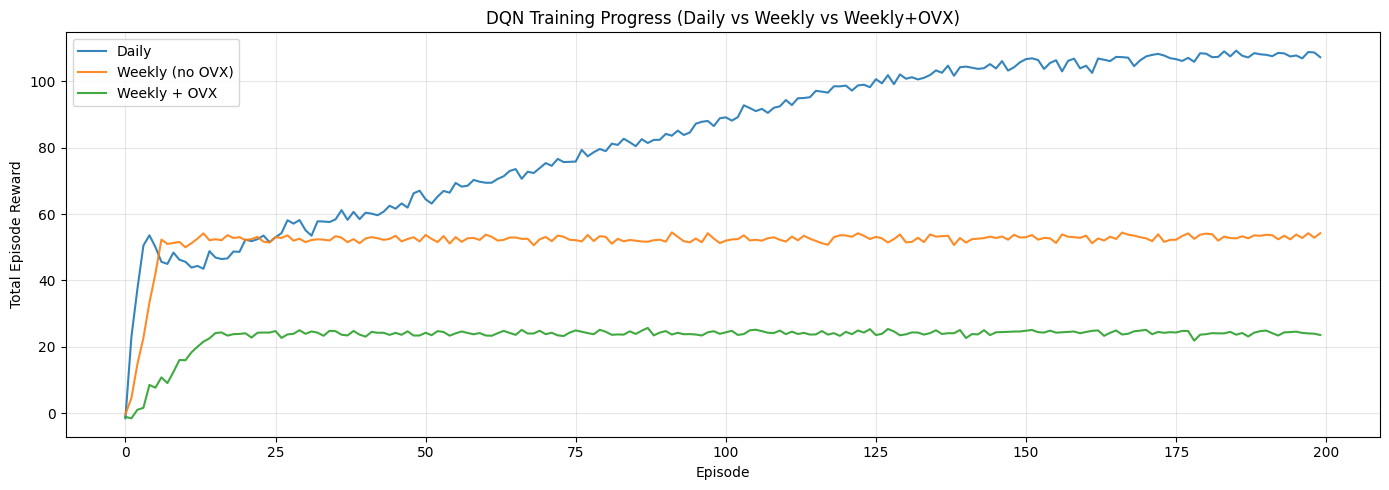

Final 10-episode avg reward (Daily):       107.9267
Final 10-episode avg reward (Weekly):      53.3390
Final 10-episode avg reward (Weekly+OVX):  24.1371


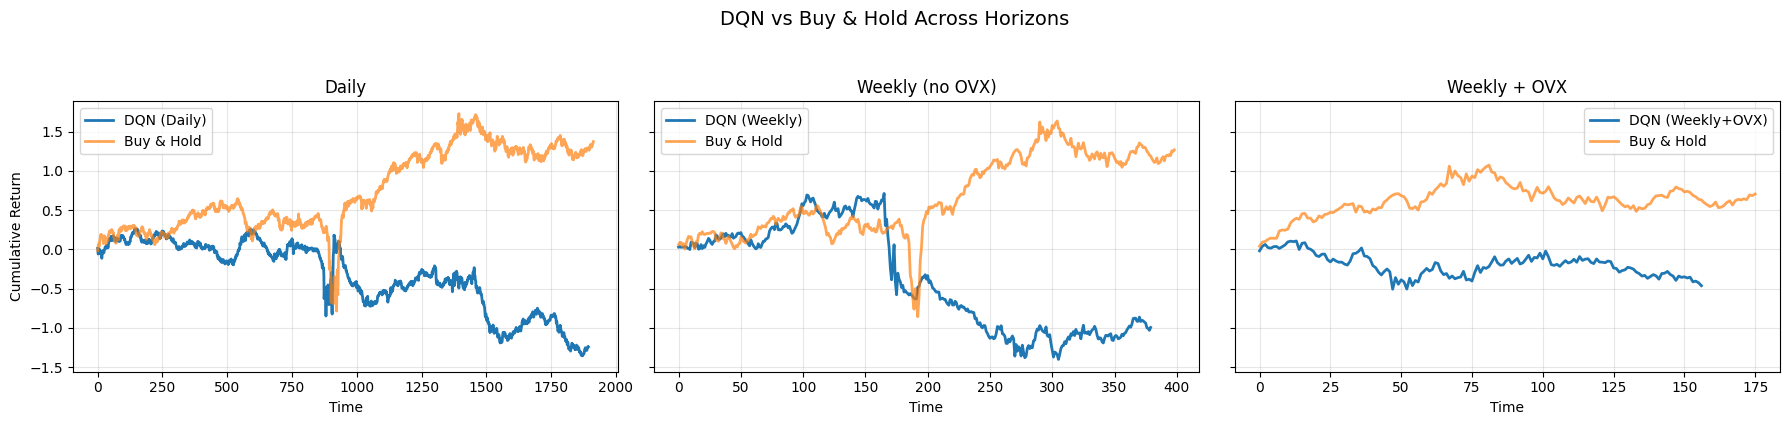

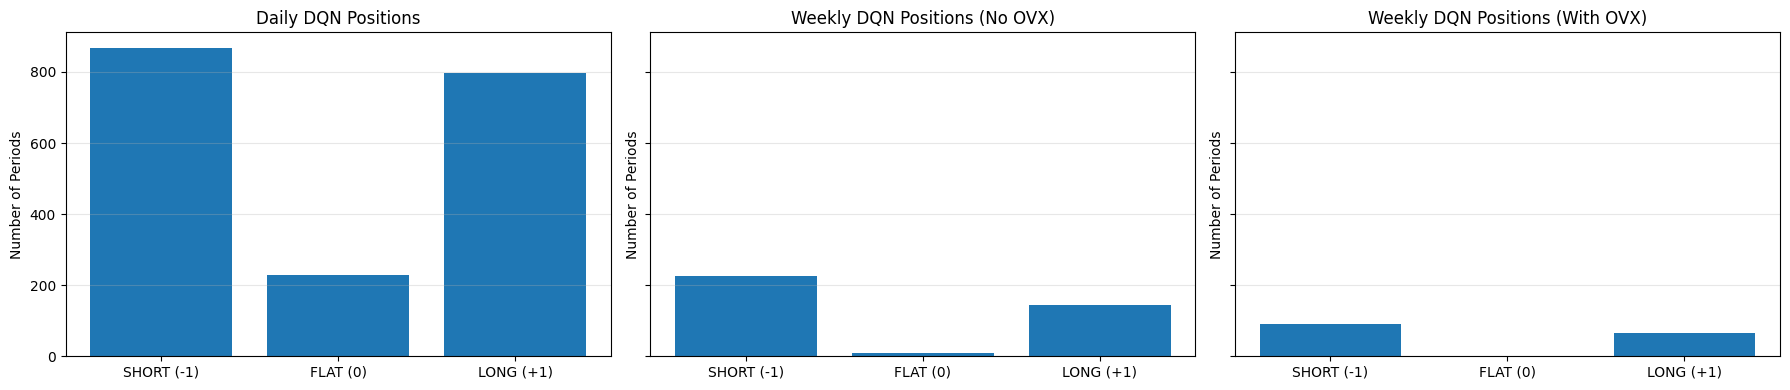

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -------------------------
# 1) TRAINING CURVES (3 models)
# -------------------------
plt.figure(figsize=(14, 5))

plt.plot(training_rewards_daily, label="Daily", alpha=0.9)
plt.plot(training_rewards_weekly, label="Weekly (no OVX)", alpha=0.9)
plt.plot(training_rewards_ovx, label="Weekly + OVX", alpha=0.9)

plt.xlabel("Episode")
plt.ylabel("Total Episode Reward")
plt.title("DQN Training Progress (Daily vs Weekly vs Weekly+OVX)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Rolling averages
window = 10
roll_daily = pd.Series(training_rewards_daily).rolling(window).mean()
roll_weekly = pd.Series(training_rewards_weekly).rolling(window).mean()
roll_ovx = pd.Series(training_rewards_ovx).rolling(window).mean()

print(f"Final {window}-episode avg reward (Daily):       {roll_daily.iloc[-1]:.4f}")
print(f"Final {window}-episode avg reward (Weekly):      {roll_weekly.iloc[-1]:.4f}")
print(f"Final {window}-episode avg reward (Weekly+OVX):  {roll_ovx.iloc[-1]:.4f}")


# -------------------------
# 2) CUMULATIVE RETURNS vs BUY & HOLD (3 panels)
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

# DAILY
dqn_cum_daily = np.cumsum(results_daily["rewards"])
bh_cum_daily = np.cumsum(test_returns_daily)

axes[0].plot(dqn_cum_daily, label="DQN (Daily)", linewidth=2)
axes[0].plot(bh_cum_daily, label="Buy & Hold", linewidth=2, alpha=0.7)
axes[0].set_title("Daily")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Cumulative Return")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# WEEKLY NO OVX
dqn_cum_weekly = np.cumsum(results_weekly["rewards"])
bh_cum_weekly = np.cumsum(test_returns_weekly)

axes[1].plot(dqn_cum_weekly, label="DQN (Weekly)", linewidth=2)
axes[1].plot(bh_cum_weekly, label="Buy & Hold", linewidth=2, alpha=0.7)
axes[1].set_title("Weekly (no OVX)")
axes[1].set_xlabel("Time")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# WEEKLY WITH OVX
dqn_cum_ovx = np.cumsum(results_ovx["rewards"])
bh_cum_ovx = np.cumsum(test_returns_ovx)

axes[2].plot(dqn_cum_ovx, label="DQN (Weekly+OVX)", linewidth=2)
axes[2].plot(bh_cum_ovx, label="Buy & Hold", linewidth=2, alpha=0.7)
axes[2].set_title("Weekly + OVX")
axes[2].set_xlabel("Time")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

fig.suptitle("DQN vs Buy & Hold Across Horizons", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()


# -------------------------
# 3) POSITION DISTRIBUTIONS (3 models)
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

def plot_positions(ax, results, title):
    positions = np.array(results["positions"])
    counts = pd.Series(positions).value_counts().sort_index()
    ax.bar(
        ["SHORT (-1)", "FLAT (0)", "LONG (+1)"],
        [counts.get(-1, 0), counts.get(0, 0), counts.get(1, 0)],
    )
    ax.set_title(title)
    ax.set_ylabel("Number of Periods")
    ax.grid(axis="y", alpha=0.3)

plot_positions(axes[0], results_daily, "Daily DQN Positions")
plot_positions(axes[1], results_weekly, "Weekly DQN Positions (No OVX)")
plot_positions(axes[2], results_ovx, "Weekly DQN Positions (With OVX)")

plt.tight_layout()
plt.show()


In [14]:
from google.colab import files
import shutil

# Zip each checkpoint directory
shutil.make_archive("daily_checkpoints", "zip", "checkpoints_daily")
shutil.make_archive("weekly_checkpoints", "zip", "checkpoints_weekly")
shutil.make_archive("weekly_ovx_checkpoints", "zip", "checkpoints_ovx")

# Download
files.download("daily_checkpoints.zip")
files.download("weekly_checkpoints.zip")
files.download("weekly_ovx_checkpoints.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>